## Textbook
- train acc의 오버피팅이 감소했을 뿐 아니라, test acc 역시 소폭 상승했네!

In [1]:
# coding: utf-8
import os
import sys
from collections import defaultdict

sys.path.append('./official_github/')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

In [2]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100
iter_per_epoch = max(train_size / batch_size, 1)


In [3]:

outputs_dict = defaultdict(list)
for weight_decay_lambda in (0, 0.1):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                            weight_decay_lambda=weight_decay_lambda)
    optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신


    epoch_cnt = 0
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            outputs_dict[f'λ={weight_decay_lambda} train_acc'].append(train_acc)
            outputs_dict[f'λ={weight_decay_lambda} test_acc'].append(test_acc)

            print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break


epoch:0, train acc:0.10666666666666667, test acc:0.0861
epoch:1, train acc:0.13333333333333333, test acc:0.0933
epoch:2, train acc:0.14666666666666667, test acc:0.1145
epoch:3, train acc:0.19333333333333333, test acc:0.1379
epoch:4, train acc:0.21333333333333335, test acc:0.1568
epoch:5, train acc:0.2833333333333333, test acc:0.1894
epoch:6, train acc:0.3233333333333333, test acc:0.2202
epoch:7, train acc:0.36333333333333334, test acc:0.2524
epoch:8, train acc:0.4033333333333333, test acc:0.2783
epoch:9, train acc:0.47333333333333333, test acc:0.3122
epoch:10, train acc:0.51, test acc:0.3465
epoch:11, train acc:0.52, test acc:0.3737
epoch:12, train acc:0.52, test acc:0.3913
epoch:13, train acc:0.5433333333333333, test acc:0.4091
epoch:14, train acc:0.5466666666666666, test acc:0.426
epoch:15, train acc:0.5666666666666667, test acc:0.4291
epoch:16, train acc:0.5833333333333334, test acc:0.4474
epoch:17, train acc:0.59, test acc:0.4558
epoch:18, train acc:0.6, test acc:0.463
epoch:19, tr

λ=0 train_acc [0.10666666666666667, 0.13333333333333333, 0.14666666666666667, 0.19333333333333333, 0.21333333333333335, 0.2833333333333333, 0.3233333333333333, 0.36333333333333334, 0.4033333333333333, 0.47333333333333333, 0.51, 0.52, 0.52, 0.5433333333333333, 0.5466666666666666, 0.5666666666666667, 0.5833333333333334, 0.59, 0.6, 0.6033333333333334, 0.64, 0.6433333333333333, 0.67, 0.71, 0.7166666666666667, 0.7466666666666667, 0.7733333333333333, 0.7866666666666666, 0.7966666666666666, 0.82, 0.8266666666666667, 0.8366666666666667, 0.8433333333333334, 0.8666666666666667, 0.8666666666666667, 0.87, 0.8866666666666667, 0.88, 0.9033333333333333, 0.8966666666666666, 0.8866666666666667, 0.91, 0.9066666666666666, 0.9066666666666666, 0.9066666666666666, 0.9066666666666666, 0.8966666666666666, 0.9266666666666666, 0.93, 0.93, 0.9333333333333333, 0.9333333333333333, 0.9366666666666666, 0.95, 0.9333333333333333, 0.95, 0.95, 0.96, 0.97, 0.9633333333333334, 0.9566666666666667, 0.9633333333333334, 0.96,

Text(0.5, 1.0, 'Textbook Weight Decay Implementation')

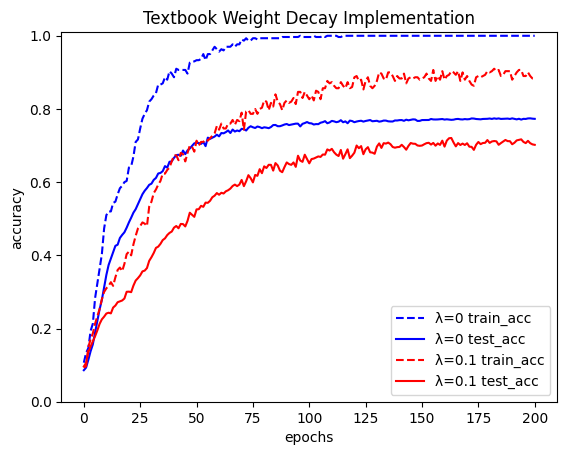

In [4]:
for key, value in outputs_dict.items():
    print(key, value)
    linestyle = 'dashed' if 'train' in key else 'solid'
    color = 'r' if key.startswith('λ=0.1') else 'b'
    
    plt.plot(value, label=key, linestyle=linestyle, color=color)

plt.legend()      
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.01)
plt.title('Textbook Weight Decay Implementation')

## My code

In [5]:
# coding: utf-8
import os
import sys
from collections import defaultdict

sys.path.append('./official_github/')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from my_models import MultiLayerNet, SGD

In [6]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100
iter_per_epoch = max(train_size / batch_size, 1)

In [7]:


outputs_dict = defaultdict(list)
for weight_decay_lambda in (0, 0.1):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                            weight_decay_method='L2',
                            weight_decay_lambda=weight_decay_lambda)
    optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신


    epoch_cnt = 0
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            outputs_dict[f'λ={weight_decay_lambda} train_acc'].append(train_acc)
            outputs_dict[f'λ={weight_decay_lambda} test_acc'].append(test_acc)

            print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break


epoch:0, train acc:0.08333333333333333, test acc:0.1037
epoch:1, train acc:0.10666666666666667, test acc:0.1088
epoch:2, train acc:0.11, test acc:0.12
epoch:3, train acc:0.14666666666666667, test acc:0.1322
epoch:4, train acc:0.21666666666666667, test acc:0.159
epoch:5, train acc:0.24666666666666667, test acc:0.1832
epoch:6, train acc:0.25666666666666665, test acc:0.2017
epoch:7, train acc:0.2966666666666667, test acc:0.2143
epoch:8, train acc:0.3566666666666667, test acc:0.2357
epoch:9, train acc:0.37333333333333335, test acc:0.251
epoch:10, train acc:0.38666666666666666, test acc:0.2651
epoch:11, train acc:0.41, test acc:0.2883
epoch:12, train acc:0.43333333333333335, test acc:0.3082
epoch:13, train acc:0.44666666666666666, test acc:0.3165
epoch:14, train acc:0.4666666666666667, test acc:0.3336
epoch:15, train acc:0.48333333333333334, test acc:0.3473
epoch:16, train acc:0.51, test acc:0.3658
epoch:17, train acc:0.5033333333333333, test acc:0.3653
epoch:18, train acc:0.503333333333333

λ=0 train_acc [0.08333333333333333, 0.10666666666666667, 0.11, 0.14666666666666667, 0.21666666666666667, 0.24666666666666667, 0.25666666666666665, 0.2966666666666667, 0.3566666666666667, 0.37333333333333335, 0.38666666666666666, 0.41, 0.43333333333333335, 0.44666666666666666, 0.4666666666666667, 0.48333333333333334, 0.51, 0.5033333333333333, 0.5033333333333333, 0.5233333333333333, 0.5366666666666666, 0.5633333333333334, 0.5533333333333333, 0.6, 0.6133333333333333, 0.64, 0.65, 0.67, 0.6833333333333333, 0.6833333333333333, 0.72, 0.7333333333333333, 0.7466666666666667, 0.7633333333333333, 0.76, 0.76, 0.7966666666666666, 0.8066666666666666, 0.8133333333333334, 0.8266666666666667, 0.8266666666666667, 0.8333333333333334, 0.83, 0.8466666666666667, 0.8333333333333334, 0.8533333333333334, 0.8666666666666667, 0.8766666666666667, 0.8833333333333333, 0.88, 0.8933333333333333, 0.8866666666666667, 0.8866666666666667, 0.9, 0.8866666666666667, 0.9033333333333333, 0.9133333333333333, 0.91, 0.9033333333

Text(0.5, 1.0, 'My Weight Decay Implementation')

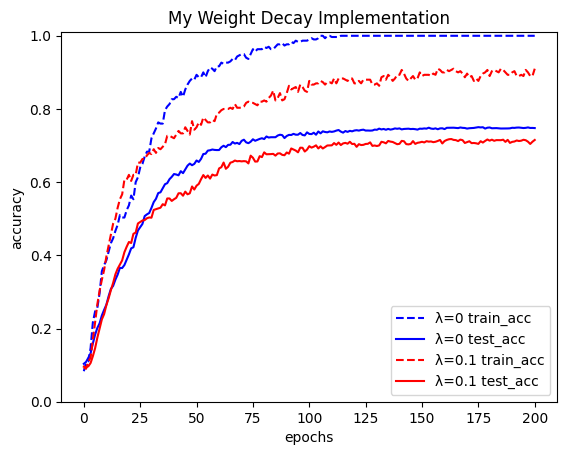

In [8]:
for key, value in outputs_dict.items():
    print(key, value)
    linestyle = 'dashed' if 'train' in key else 'solid'
    color = 'r' if key.startswith('λ=0.1') else 'b'
    
    plt.plot(value, label=key, linestyle=linestyle, color=color)

plt.legend()      
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.01)
plt.title('My Weight Decay Implementation')

## what about L1 regularization?
- 규제가 아무래도 조금 약한가?

In [1]:
# coding: utf-8
import os
import sys
from collections import defaultdict

sys.path.append('./official_github/')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from my_models import MultiLayerNet, SGD

In [2]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100
iter_per_epoch = max(train_size / batch_size, 1)

In [9]:


outputs_dict = defaultdict(list)
for weight_decay_lambda in (0, 0.1):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                            weight_decay_method='L1',
                            weight_decay_lambda=weight_decay_lambda)
    optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신


    epoch_cnt = 0
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            outputs_dict[f'λ={weight_decay_lambda} train_acc'].append(train_acc)
            outputs_dict[f'λ={weight_decay_lambda} test_acc'].append(test_acc)

            print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break


epoch:0, train acc:0.09666666666666666, test acc:0.1141
epoch:1, train acc:0.11333333333333333, test acc:0.1193
epoch:2, train acc:0.13333333333333333, test acc:0.1365
epoch:3, train acc:0.14333333333333334, test acc:0.1452
epoch:4, train acc:0.18, test acc:0.1593
epoch:5, train acc:0.21, test acc:0.1779
epoch:6, train acc:0.23666666666666666, test acc:0.1953
epoch:7, train acc:0.25666666666666665, test acc:0.2155
epoch:8, train acc:0.29333333333333333, test acc:0.2357
epoch:9, train acc:0.3433333333333333, test acc:0.2637
epoch:10, train acc:0.35333333333333333, test acc:0.2719
epoch:11, train acc:0.42333333333333334, test acc:0.3103
epoch:12, train acc:0.4766666666666667, test acc:0.3519
epoch:13, train acc:0.5133333333333333, test acc:0.378
epoch:14, train acc:0.54, test acc:0.3939
epoch:15, train acc:0.5566666666666666, test acc:0.412
epoch:16, train acc:0.5933333333333334, test acc:0.4433
epoch:17, train acc:0.5866666666666667, test acc:0.4528
epoch:18, train acc:0.643333333333333

λ=0 train_acc [0.09666666666666666, 0.11333333333333333, 0.13333333333333333, 0.14333333333333334, 0.18, 0.21, 0.23666666666666666, 0.25666666666666665, 0.29333333333333333, 0.3433333333333333, 0.35333333333333333, 0.42333333333333334, 0.4766666666666667, 0.5133333333333333, 0.54, 0.5566666666666666, 0.5933333333333334, 0.5866666666666667, 0.6433333333333333, 0.6666666666666666, 0.6833333333333333, 0.6833333333333333, 0.6933333333333334, 0.7066666666666667, 0.6866666666666666, 0.72, 0.7266666666666667, 0.7366666666666667, 0.7533333333333333, 0.7466666666666667, 0.75, 0.7666666666666667, 0.7833333333333333, 0.8, 0.7933333333333333, 0.82, 0.8, 0.82, 0.8433333333333334, 0.84, 0.8466666666666667, 0.8633333333333333, 0.8733333333333333, 0.88, 0.88, 0.8966666666666666, 0.9033333333333333, 0.9066666666666666, 0.9266666666666666, 0.9166666666666666, 0.92, 0.9266666666666666, 0.9133333333333333, 0.9266666666666666, 0.9366666666666666, 0.9333333333333333, 0.9266666666666666, 0.9333333333333333, 

Text(0.5, 1.0, 'My L1 Regularization Implementation')

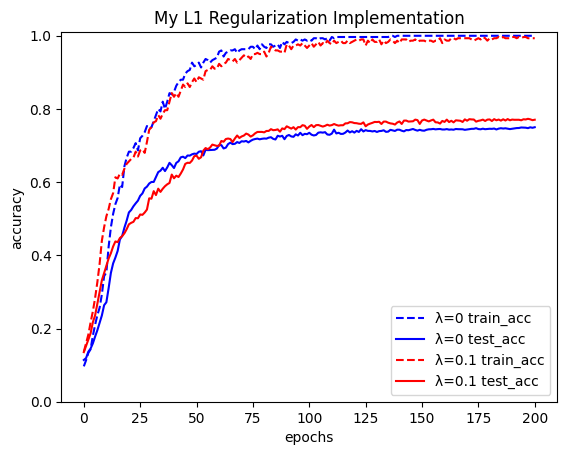

In [10]:
colors = ['r', 'r', 'b', 'b']
for key, value in outputs_dict.items():
    print(key, value)
    linestyle = 'dashed' if 'train' in key else 'solid'
    
    color = colors.pop()
    
    plt.plot(value, label=key, linestyle=linestyle, color=color)

plt.legend()      
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.01)
plt.title('My L1 Regularization Implementation')